# Exploratary Data Analysis

The idea here is simply to get a feel for the data we will later study

In [1]:
asset_name = 'SOL'

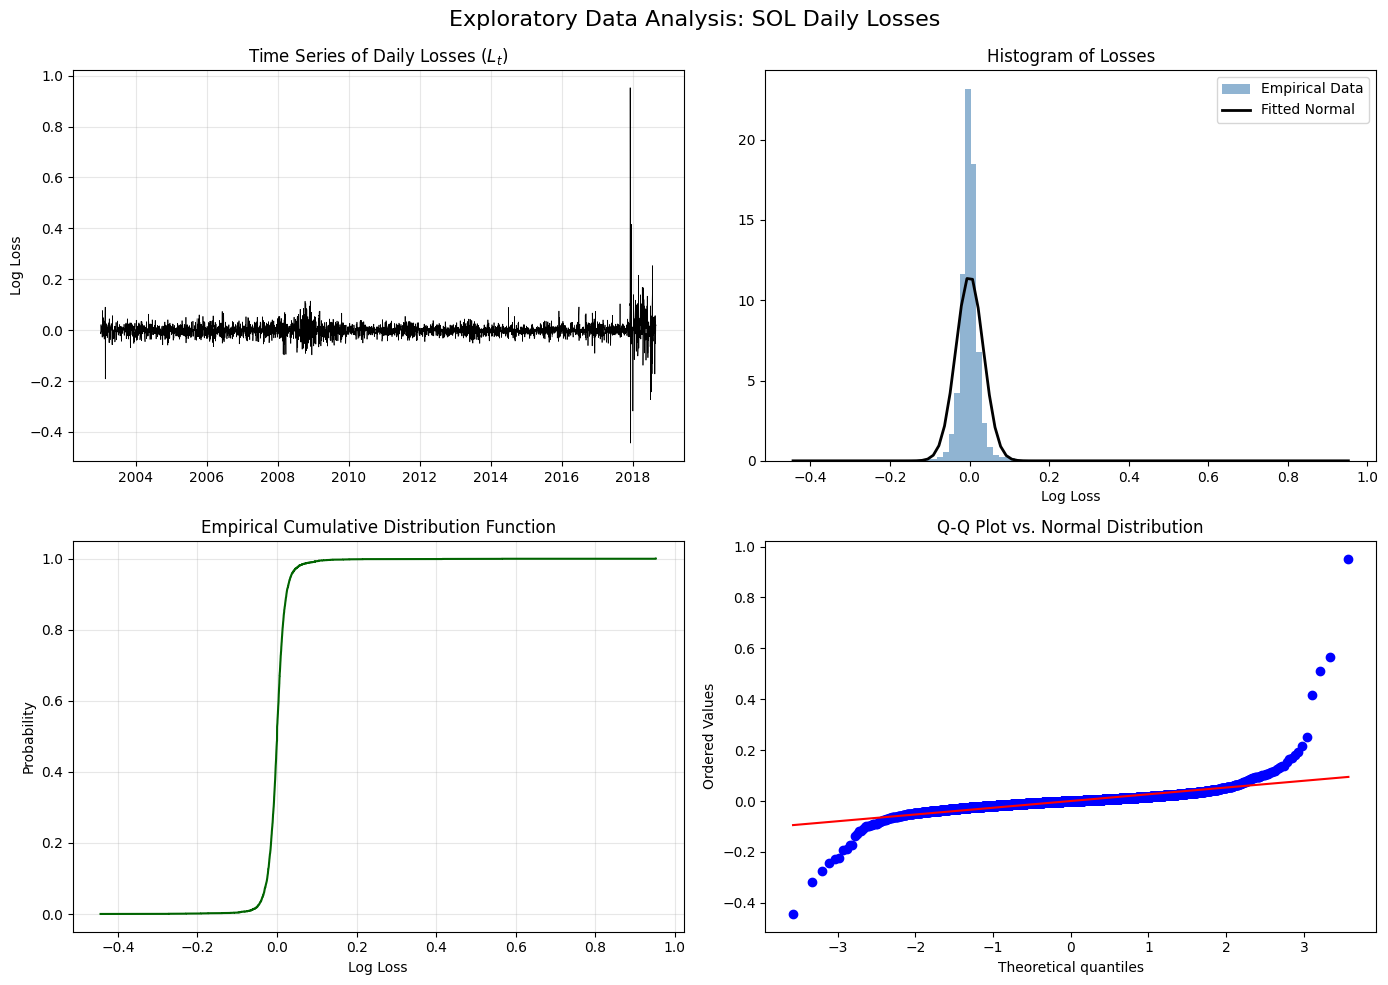

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os


data_path = f'../data/asset_analysis/{asset_name}_analysis.csv'
df = pd.read_csv(data_path, parse_dates=['date'], index_col='date')

os.makedirs('../report/figures', exist_ok=True)
losses = df['Loss'].dropna()

# 2. Initialize the plotting figure (MUST STAY IN THE SAME CELL AS PLOTTING COMMANDS)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Exploratory Data Analysis: {asset_name} Daily Losses', fontsize=16)

# --- Plot A: Loss Time Series ---
axes[0, 0].plot(df.index, losses, color='black', linewidth=0.5)
axes[0, 0].set_title('Time Series of Daily Losses ($L_t$)')
axes[0, 0].set_ylabel('Log Loss')
axes[0, 0].grid(True, alpha=0.3)

# --- Plot B: Histogram vs. Normal Distribution ---
mu, std = stats.norm.fit(losses)
xmin, xmax = losses.min(), losses.max()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

axes[0, 1].hist(losses, bins=100, density=True, alpha=0.6, color='steelblue', label='Empirical Data')
axes[0, 1].plot(x, p, 'k', linewidth=2, label='Fitted Normal')
axes[0, 1].set_title('Histogram of Losses')
axes[0, 1].set_xlabel('Log Loss')
axes[0, 1].legend()

# --- Plot C: Empirical CDF ---
x_ecdf = np.sort(losses)
y_ecdf = np.arange(1, len(x_ecdf) + 1) / len(x_ecdf)

axes[1, 0].step(x_ecdf, y_ecdf, where='post', color='darkgreen')
axes[1, 0].set_title('Empirical Cumulative Distribution Function')
axes[1, 0].set_xlabel('Log Loss')
axes[1, 0].set_ylabel('Probability')
axes[1, 0].grid(True, alpha=0.3)

# --- Plot D: Q-Q Plot ---
stats.probplot(losses, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot vs. Normal Distribution')

# 3. Adjust layout, save, and show
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(f'../report/figures/{asset_name}_eda_plots.png', dpi=300)
plt.show()